In [1]:
# Import the module
import importlib
import IsovizPy as ja
import pandas as pd
import gffutils

In [2]:
!hostname

ne1dc6-005.nygenome.org


In [3]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = '/gpfs/commons/home/kisaev/gencode.v47.basic.annotation.gtf'  
#db = ja.create_db(gtf_file, "human_v47_gencode_basic")

In [4]:
# Path to the database file created previously
db_path = "human_v47_gencode_basic"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

In [5]:
gene_name = 'BCL2L1'

In [6]:
# After making changes to IsovizPy, reload it
importlib.reload(ja)

<module 'IsovizPy' from '/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/IsovizPy.py'>

In [7]:
# Example usage when transcripts_list 
new_order = ['ENST00000553185.2', 'ENST00000675868.2', 'ENST00000681700.1',
       'ENST00000680189.1', 'ENST00000680934.1', 'ENST00000679494.1',
       'ENST00000681228.1', 'ENST00000680659.1', 'ENST00000679987.1',
       'ENST00000202917.10', 'ENST00000679467.1', 'ENST00000445409.7',
       'ENST00000540589.3', 'ENST00000552526.2', 'ENST00000679971.1',
       'ENST00000680455.1', 'ENST00000550689.2', 'ENST00000679841.1',
       'ENST00000550883.2', 'ENST00000553152.2', 'ENST00000452357.7',
       'ENST00000551241.6']

new_order = ["ENST00000677494.1",
"ENST00000456404.6",
"ENST00000678563.1",
"ENST00000676942.1",
"ENST00000420488.6",
"ENST00000439267.2",
"ENST00000307677.5",
"ENST00000376062.6",
"ENST00000677194.1",
"ENST00000434194.2",
"ENST00000450273.2",
"ENST00000376055.9",
"ENST00000422920.2",
"ENST00000676582.1",
"ENST00000678671.1"]

new_order = new_order[::-1]

In [167]:
transcript_ids = ja.fetch_transcripts_for_gene(db, gene_name)
transcript_ids = new_order

# Step 2: Fetch transcript annotations
transcript_data = ja.fetch_transcripts_and_annotations(db, new_order)
    
# Step 3: Determine region boundaries
region_start, region_end = ja.determine_region_boundaries_from_transcripts(transcript_data)

Plot saved to BCL2L1_isoforms_plot_20241112.pdf!


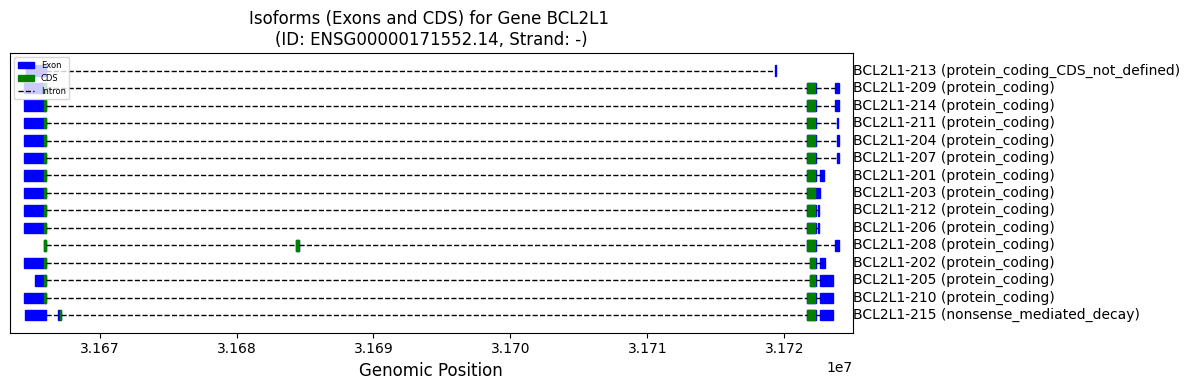

In [168]:
# Step 4: Plot isoforms
ja.plot_isoforms(db, transcript_data, region_start-1000, region_end+1000, base_width=12, trans_height=0.2)